# Spotify Charts: Data Prep & Exploratory Analysis

**Question:** what does a song's life on the charts look like, how concentrated is streaming, and what separates songs that climb and stay from short spikes?

**Data:** [Spotify Charts (dhruvildave)](https://www.kaggle.com/datasets/dhruvildave/spotify-charts), real daily Top 200 charts. The raw file is ~26M rows (3.4GB). It was filtered to the **United States** and **Global** Top 200 charts for 2017-2021, giving the ~726K-row slice loaded below. The raw file stays local; this notebook reads the committed, gzipped slice.

This is a portfolio project. Findings are for skill demonstration, not label strategy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Analysis-ready slice: US + Global, Top 200, 2017-2021 (filtered from the 3.4GB raw file)
df = pd.read_csv("../data/spotify_us_global_top200.csv.gz")
df["date"] = pd.to_datetime(df["date"])
print("shape:", df.shape)
df.head()

shape: (726366, 9)


## 1. Validate the slice

Confirm regions, chart type, date coverage, and that there are no nulls before analyzing. Coverage is near-complete: ~200 songs per day with only a handful of missing days across five years.

In [2]:
# Validation: confirm the slice is what we expect
print("regions:", df["region"].value_counts().to_dict())
print("charts:", df["chart"].unique().tolist())
print("date range:", df["date"].min().date(), "->", df["date"].max().date())
print("rank range:", df["rank"].min(), "-", df["rank"].max())
print("trend values:", df["trend"].unique().tolist())
print("unique tracks (url):", df["url"].nunique(), "| unique artists:", df["artist"].nunique())
print("\nnulls:\n", df.isnull().sum())

regions: {'United States': 364184, 'Global': 362182}
charts: ['top200']
date range: 2017-01-01 -> 2021-12-31
rank range: 1 - 200
trend values: ['SAME_POSITION', 'MOVE_UP', 'MOVE_DOWN', 'NEW_ENTRY']
unique tracks (url): 11132 | unique artists: 2918

nulls:
 title      0
rank       0
date       0
artist     0
url        0
region     0
chart      0
trend      0
streams    0
dtype: int64


## 2. How long do songs stay on the chart?

One modeling decision first: the same song can appear under several Spotify URLs (single vs. album vs. re-release), which would split its chart life across rows. To avoid that, a song is keyed by **title + artist**, taking its best rank each day. Collapsing to one row per song shows most are short-lived, with a long tail that lives on for months.

distinct songs that charted in the US: 7878
days on chart - {'mean': 46.2, '50%': 6.0, 'max': 1778.0}


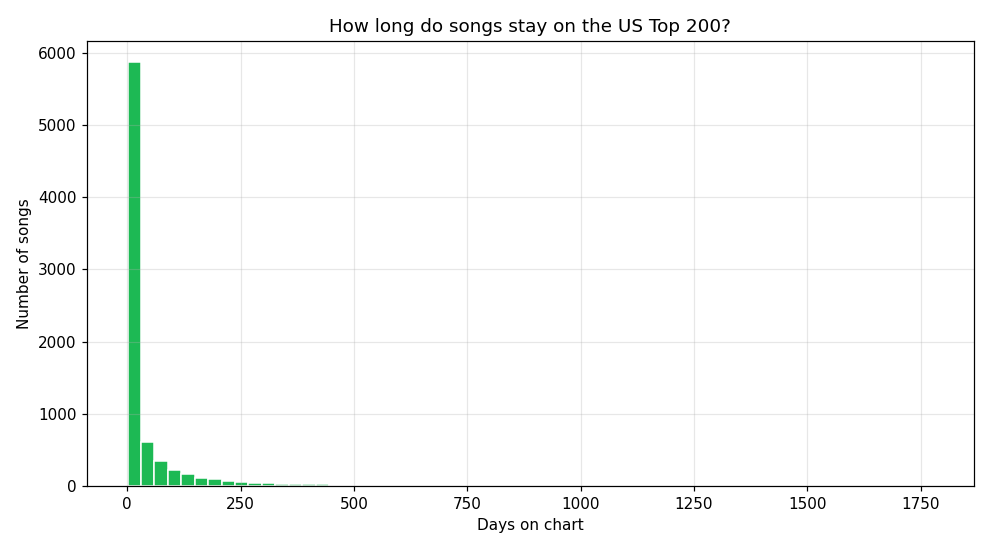

In [3]:
# A song can appear under several Spotify URLs (single, album, re-release), which would
# fragment its chart life. So treat a song as (title + artist) and take its BEST rank each day.
us = df[df["region"] == "United States"].copy()
us["song"] = us["title"] + "  -  " + us["artist"]

daily_song = (us.groupby(["song", "date"])
                .agg(rank=("rank", "min"), streams=("streams", "sum"))
                .reset_index())

runs = (daily_song.sort_values(["song", "date"]).groupby("song")
        .agg(debut_rank=("rank", "first"),
             debut_date=("date", "first"),
             days_on_chart=("date", "nunique"),
             peak_rank=("rank", "min"),
             total_streams=("streams", "sum")))

print("distinct songs that charted in the US:", len(runs))
print("days on chart -",
      runs["days_on_chart"].describe()[["mean", "50%", "max"]].round(1).to_dict())

fig, ax = plt.subplots()
ax.hist(runs["days_on_chart"], bins=60, color="#1DB954", edgecolor="white")
ax.set_title("How long do songs stay on the US Top 200?")
ax.set_xlabel("Days on chart"); ax.set_ylabel("Number of songs")
plt.tight_layout(); plt.savefig("../data/fig_days_on_chart.png", dpi=110); plt.show()

## 3. Debut rank vs. peak rank

Few songs debut at the very top. Most enter low and climb, which is exactly the movement the SQL layer will quantify.

11.1% of charting songs ever reached the top 10
55.2% of charting songs lasted a week or less


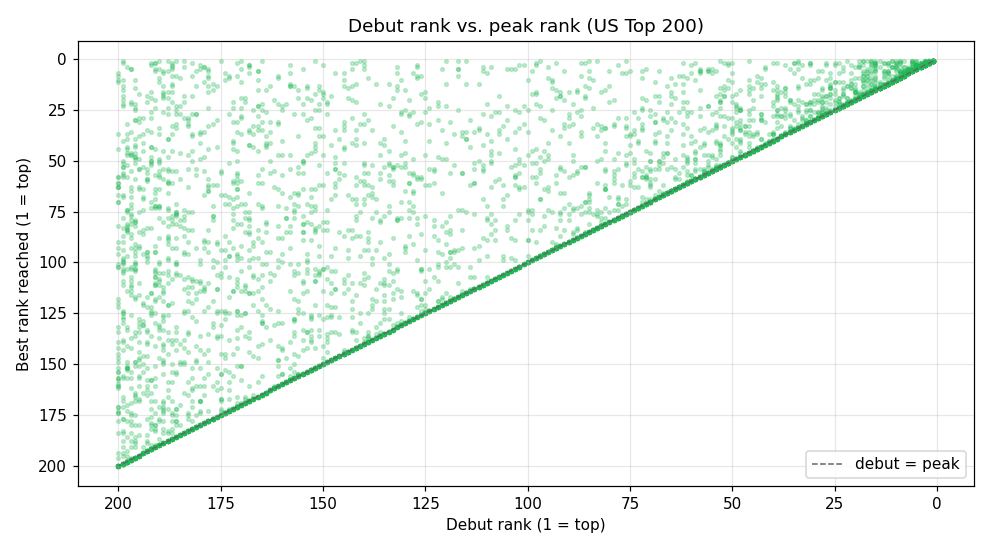

In [4]:
# Where do songs debut vs. how high do they peak?
reached_top10 = (runs["peak_rank"] <= 10).mean() * 100
one_week = (runs["days_on_chart"] <= 7).mean() * 100
print(f"{reached_top10:.1f}% of charting songs ever reached the top 10")
print(f"{one_week:.1f}% of charting songs lasted a week or less")

fig, ax = plt.subplots()
ax.scatter(runs["debut_rank"], runs["peak_rank"], s=6, alpha=0.25, color="#1DB954")
ax.plot([1, 200], [1, 200], color="0.4", lw=1, ls="--", label="debut = peak")
ax.set_title("Debut rank vs. peak rank (US Top 200)")
ax.set_xlabel("Debut rank (1 = top)"); ax.set_ylabel("Best rank reached (1 = top)")
ax.invert_xaxis(); ax.invert_yaxis(); ax.legend()
plt.tight_layout(); plt.savefig("../data/fig_debut_vs_peak.png", dpi=110); plt.show()

## 4. Streaming concentration

A small number of songs capture a large share of streams: the Pareto shape every product team cares about.

top  1% of songs capture 21.0% of US streams
top  5% of songs capture 55.2% of US streams
top 10% of songs capture 73.1% of US streams


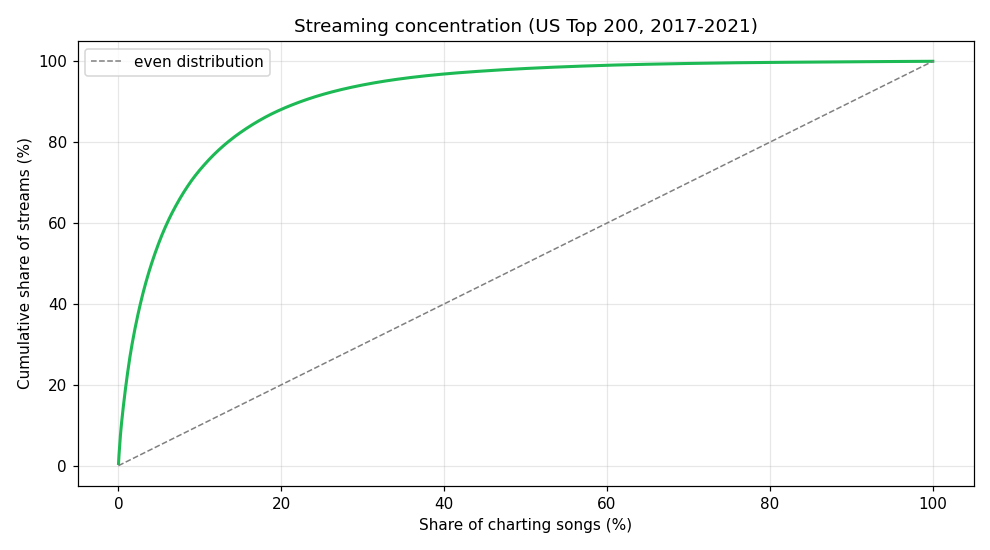

In [5]:
# Streaming concentration: what share of streams do the biggest songs capture?
song_streams = runs["total_streams"].sort_values(ascending=False)
cum_share = song_streams.cumsum() / song_streams.sum()
x = np.arange(1, len(cum_share) + 1) / len(cum_share)

for p in (0.01, 0.05, 0.10):
    idx = max(int(p * len(cum_share)) - 1, 0)
    print(f"top {p*100:>2.0f}% of songs capture {cum_share.values[idx]*100:4.1f}% of US streams")

fig, ax = plt.subplots()
ax.plot(x * 100, cum_share.values * 100, color="#1DB954", lw=2)
ax.plot([0, 100], [0, 100], color="0.5", lw=1, ls="--", label="even distribution")
ax.set_title("Streaming concentration (US Top 200, 2017-2021)")
ax.set_xlabel("Share of charting songs (%)"); ax.set_ylabel("Cumulative share of streams (%)")
ax.legend()
plt.tight_layout(); plt.savefig("../data/fig_concentration.png", dpi=110); plt.show()

## 5. Climbers vs. spikes

Two real songs, picked by the data: one that entered low and climbed into the top 5 over years, and one short seasonal spike that charted high for a few days and vanished.

Climber: All Girls Are The Same  -  Juice WRLD | debut 191 -> peak 5 over 1342 days
Spike:   This Is Halloween  -  Disney Characters | peak 7 in 5 days


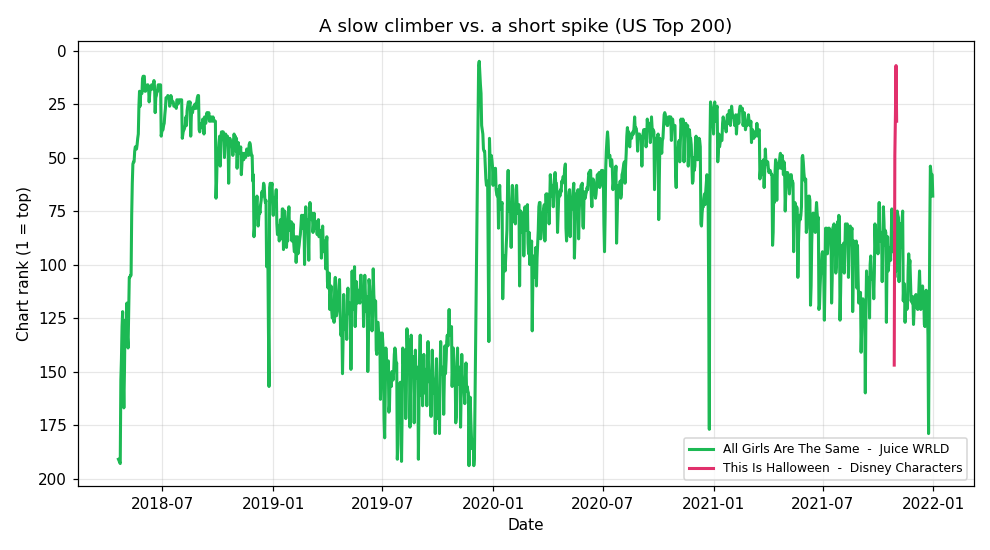

In [6]:
# Two real life stories, chosen by the data: a slow climber vs. a short spike
climbers = runs[(runs["peak_rank"] <= 5) & (runs["debut_rank"] >= 80) &
                (runs["days_on_chart"] >= 150)].sort_values("days_on_chart", ascending=False)
spikes = runs[(runs["days_on_chart"] <= 5) & (runs["peak_rank"] <= 130)].sort_values("peak_rank")

climber = climbers.index[0]
spike = spikes.index[0]

fig, ax = plt.subplots()
for song, color in [(climber, "#1DB954"), (spike, "#E1306C")]:
    t = daily_song[daily_song["song"] == song].sort_values("date")
    ax.plot(t["date"], t["rank"], color=color, lw=2, label=song[:46])
ax.set_title("A slow climber vs. a short spike (US Top 200)")
ax.set_xlabel("Date"); ax.set_ylabel("Chart rank (1 = top)")
ax.invert_yaxis(); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("../data/fig_climber_vs_spike.png", dpi=110); plt.show()

print("Climber:", climber, "| debut", int(runs.loc[climber, "debut_rank"]),
      "-> peak", int(runs.loc[climber, "peak_rank"]), "over", int(runs.loc[climber, "days_on_chart"]), "days")
print("Spike:  ", spike, "| peak", int(runs.loc[spike, "peak_rank"]),
      "in", int(runs.loc[spike, "days_on_chart"]), "days")

## 6. Total streams over time

Daily streaming volume trends up across the window, useful context for any rate-based metric.

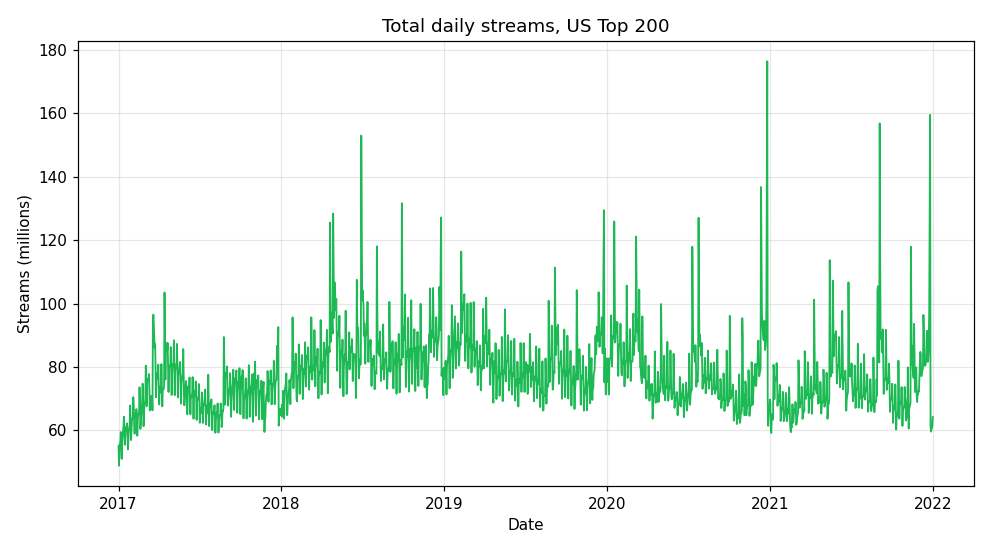

In [7]:
# Total daily streams over time (US)
daily = daily_song.groupby("date")["streams"].sum()
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values / 1e6, color="#1DB954", lw=1.2)
ax.set_title("Total daily streams, US Top 200")
ax.set_xlabel("Date"); ax.set_ylabel("Streams (millions)")
plt.tight_layout(); plt.savefig("../data/fig_streams_over_time.png", dpi=110); plt.show()

## Takeaways & next steps

- Most songs are short-lived; staying power is rare and worth flagging early.
- Streaming is heavily concentrated in a small set of songs.
- The interesting movement is the climb from a low debut to a high peak.

**Next:** the SQL layer quantifies these with window functions (LAG for week-over-week rank and stream deltas, FIRST_VALUE for debut rank, NTILE for concentration tiers), then the Power BI dashboard makes the chart dynamics interactive.